# Mario's Braille Translator — Phase 2 (Final Academic Version)
> **YOLO11s** fine-tuned on the Angelina Braille dataset (63 classes).



## Step 1 — Mount Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Install YOLO, Gradio, Groq
!pip install ultralytics gradio groq -q


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 15.5 MB/s eta 0:00:00


### Test 1 — Verify Installations

In [2]:
# ── TEST CELL 1: check library versions ──────────────────
import importlib, sys

required = ['ultralytics', 'gradio', 'cv2', 'numpy']
all_ok = True
for lib in required:
    try:
        m = importlib.import_module(lib)
        ver = getattr(m, '__version__', 'n/a')
        print(f'✅ {lib} == {ver}')
    except ImportError:
        print(f'❌ {lib} NOT found')
        all_ok = False

assert all_ok, 'One or more libraries missing — re-run Cell 0'
print('\n🎉 All dependencies OK')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ ultralytics == 8.4.51
✅ gradio == 5.50.0
✅ cv2 == 4.13.0
✅ numpy == 2.0.2

🎉 All dependencies OK


## Step 2 — Create `braille_books.yaml`


In [3]:
import os

# ── EDIT THIS PATH ────────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
# ──────────────────────────────────────────────────────────

yaml_content = f"""
train: {BASE_PATH}/train_all.txt
val:   {BASE_PATH}/val_all.txt

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""

with open('braille_books.yaml', 'w') as f:
    f.write(yaml_content)

print('✅ braille_books.yaml created successfully')
print(yaml_content)


✅ braille_books.yaml created successfully

train: /content/drive/MyDrive/ML Project/AngelinaDataset/books/train_all.txt
val:   /content/drive/MyDrive/ML Project/AngelinaDataset/books/val_all.txt

nc: 63
names: [ '1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31','32','33','34','35','36','37','38','39','40','41','42','43','44','45','46','47','48','49','50','51','52','53','54','55','56','57','58','59','60','61','62','63' ]



### Test 2 — Validate YAML Contents

In [4]:
# ── TEST CELL 2: validate YAML ───────────────────────────
import yaml, os

assert os.path.exists('braille_books.yaml'), '❌ YAML file not found'

with open('braille_books.yaml') as f:
    cfg = yaml.safe_load(f)

assert cfg.get('nc') == 63,           f'❌ nc should be 63, got {cfg.get("nc")}'
assert len(cfg.get('names', [])) == 63, f'❌ names list length {len(cfg.get("names",[]))} != 63'
assert 'train' in cfg,                '❌ train key missing'
assert 'val'   in cfg,                '❌ val key missing'

print('✅ YAML is valid')
print(f"   train → {cfg['train']}")
print(f"   val   → {cfg['val']}")
print(f"   nc    → {cfg['nc']}")


✅ YAML is valid
   train → /content/drive/MyDrive/ML Project/AngelinaDataset/books/train_all.txt
   val   → /content/drive/MyDrive/ML Project/AngelinaDataset/books/val_all.txt
   nc    → 63


## Step 3 — Fix Image Paths in train/val txt Files

In [5]:
import os

DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"

def fix_paths(file_name):
    """Rewrite each line in a .txt split file to the correct absolute path."""
    full_path = os.path.join(DATASET_PATH, file_name)
    if not os.path.exists(full_path):
        print(f'⚠️  {file_name} not found — skipping')
        return

    with open(full_path, 'r') as f:
        lines = f.readlines()

    corrected, missing = [], []
    for line in lines:
        img_name = os.path.basename(line.strip())
        found = False
        for root, _, files in os.walk(DATASET_PATH):
            if img_name in files:
                corrected.append(os.path.join(root, img_name) + '\n')
                found = True
                break
        if not found:
            missing.append(img_name)

    with open(full_path, 'w') as f:
        f.writelines(corrected)

    print(f'✅ {file_name}: {len(corrected)} paths fixed, {len(missing)} missing')
    if missing:
        print(f'   Missing examples: {missing[:5]}')

fix_paths('train_all.txt')
fix_paths('val_all.txt')


✅ train_all.txt: 180 paths fixed, 0 missing
✅ val_all.txt: 32 paths fixed, 0 missing


### Test 3 — Spot-check Fixed Path Files

In [6]:
# ── TEST CELL 3: spot-check path files ───────────────────
import os

DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"

for split in ['train_all.txt', 'val_all.txt']:
    fpath = os.path.join(DATASET_PATH, split)
    if not os.path.exists(fpath):
        print(f'⚠️  {split} not found — skipping test')
        continue
    with open(fpath) as f:
        lines = [l.strip() for l in f if l.strip()]
    bad = [l for l in lines[:20] if not os.path.isabs(l)]
    print(f'📄 {split}: {len(lines)} entries')
    if bad:
        print(f'  ❌ Non-absolute paths found: {bad[:3]}')
    else:
        print(f'  ✅ First 20 paths are absolute')
    print(f'  Sample: {lines[0] if lines else "(empty)"}')


📄 train_all.txt: 180 entries
  ✅ First 20 paths are absolute
  Sample: /content/drive/MyDrive/ML Project/AngelinaDataset/books/skazki/IMG_20190715_121157.labeled.jpg
📄 val_all.txt: 32 entries
  ✅ First 20 paths are absolute
  Sample: /content/drive/MyDrive/ML Project/AngelinaDataset/books/skazki/IMG_20190715_121240.labeled.jpg


## Step 4 — Train YOLO11s with Heavy Augmentation



In [10]:
# ══════════════════════════════════════════════════════════════
#  STEP 4 — THREE-MODEL TRAINING  (Baseline → Primary → Large)
# ══════════════════════════════════════════════════════════════

# ── Auto-install guard ────────────────────────────────────────
try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    import subprocess; subprocess.run(['pip','install','ultralytics','-q'], check=True)
    from ultralytics import YOLO

import os, yaml as _yaml

# ── Shared paths ──────────────────────────────────────────────
BASE_PATH  = '/content/drive/MyDrive/ML Project/AngelinaDataset/books'
RUNS_DIR   = '/content/drive/MyDrive/ML Project/YOLO_Runs'
YAML_PATH  = '/content/braille_books.yaml'

# ── Re-create YAML inline (runtime-reset guard) ───────────────
if not os.path.exists(YAML_PATH):
    with open(YAML_PATH, 'w') as _f:
        _yaml.dump({
            'train': f'{BASE_PATH}/train_all.txt',
            'val':   f'{BASE_PATH}/val_all.txt',
            'nc': 63,
            'names': [str(i+1) for i in range(63)],
        }, _f)
    print('✅ YAML re-created')

# ── Shared hyperparameters (identical across all 3 models) ────
SHARED_HP = dict(
    data          = YAML_PATH,
    epochs        = 100,
    imgsz         = 1024,
    batch         = 4,
    project       = RUNS_DIR,
    device        = 0,           # GPU; change to 'cpu' if needed
    exist_ok      = True,
    seed          = 42,           # full reproducibility
    # ── Early stopping ────────────────────────────────────────
    patience      = 15,           # halt if val mAP flat for 15 epochs
    # ── LR schedule ──────────────────────────────────────────
    warmup_epochs = 5,            # gradual ramp — stabilises 63-class head
    cos_lr        = True,         # cosine decay > step decay for fine-grained cls
    # ── Regularisation ───────────────────────────────────────
    label_smoothing = 0.1,        # softens overconfidence on dot-pattern lookalikes
    amp           = True,         # mixed precision — ~40% less GPU memory
    overlap_mask  = False,        # prevents mask conflicts with copy_paste
    # ── Augmentation (class-imbalance correction) ─────────────
    mosaic        = 1.0,
    mixup         = 0.2,
    copy_paste    = 0.3,
    cls           = 2.0,
)

# ── MODEL 1 — Baseline (YOLO11n, nano) ───────────────────────
print('\n' + '='*60)
print('  MODEL 1 — YOLO11n  (Baseline — lightest family member)')
print('='*60)
model_nano = YOLO('yolo11n.pt')
res_nano   = model_nano.train(name='Braille_YOLO11n_Baseline', **SHARED_HP)
nano_best  = str(res_nano.save_dir) + '/weights/best.pt'
print(f'✅ Baseline saved → {nano_best}')

# ── MODEL 2 — Primary (YOLO11s, small) ───────────────────────
print('\n' + '='*60)
print('  MODEL 2 — YOLO11s  (Primary — best speed/accuracy tradeoff)')
print('='*60)
model_small = YOLO('yolo11s.pt')
res_small   = model_small.train(name='Braille_YOLO11s_Primary', **SHARED_HP)
small_best  = str(res_small.save_dir) + '/weights/best.pt'
print(f'✅ Primary saved → {small_best}')

# ── MODEL 3 — Large (YOLO11m, medium) ────────────────────────
print('\n' + '='*60)
print('  MODEL 3 — YOLO11m  (Large — upper-bound reference)')
print('='*60)
model_med = YOLO('yolo11m.pt')
res_med   = model_med.train(name='Braille_YOLO11m_Large', **SHARED_HP)
med_best  = str(res_med.save_dir) + '/weights/best.pt'
print(f'✅ Large saved → {med_best}')

print('\n🎉 All 3 models trained. Proceed to Step 5 for evaluation.')
print(f'   Nano   → {nano_best}')
print(f'   Small  → {small_best}')
print(f'   Medium → {med_best}')



  MODEL 1 — YOLO11n  (Baseline — lightest family member)
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/braille_books.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11n.pt, momentum=0.937, mosaic

### Test 4 — Verify Saved Weights Exist

In [11]:
# ── TEST CELL 4: verify all 3 model weights exist ────────────
import os, glob

RUNS_DIR = '/content/drive/MyDrive/ML Project/YOLO_Runs'
all_weights = sorted(glob.glob(os.path.join(RUNS_DIR,'**','best.pt'), recursive=True),
                     key=os.path.getmtime)

if all_weights:
    for w in all_weights:
        size_mb = os.path.getsize(w) / 1e6
        print(f'✅ {os.path.basename(os.path.dirname(os.path.dirname(w)))}  →  {size_mb:.1f} MB')
        print(f'   Path: {w}')
else:
    print('❌ No best.pt found — did training finish?')

expected = ['YOLO11n','YOLO11s','YOLO11m']
found_names = [os.path.basename(os.path.dirname(os.path.dirname(w))) for w in all_weights]
print(f'\nModels found: {len(all_weights)}/3')


✅ braille_Product_Final  →  6.3 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Final/weights/best.pt
✅ braille_v1  →  6.3 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_v1/weights/best.pt
✅ braille_Product_Augmented2  →  6.3 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Augmented2/weights/best.pt
✅ braille_YOLO_Small_Synthetic_Merged  →  22.6 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Synthetic_Merged/weights/best.pt
✅ braille_books_v13  →  6.3 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_books_v13/weights/best.pt
✅ braille_YOLO_Small_Final-2  →  22.6 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Final-2/weights/best.pt
✅ braille_books_v2_HighRes  →  6.3 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Runs/braille_books_v2_HighRes/weights/best.pt
✅ Mario_Braille_YOLO11s_Final  →  19.3 MB
   Path: /content/drive/MyDrive/ML Project/YOLO_Ru

## Step 6 — Model Evaluation & Academic Metric Analysis



🔍 Found 11 model weight(s):
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Final/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_v1/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Augmented2/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Synthetic_Merged/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_books_v13/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Final-2/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/braille_books_v2_HighRes/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/Mario_Braille_YOLO11s_Final/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/Braille_YOLO11n_Baseline/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/Braille_YOLO11s_Primary/weights/best.pt
   /content/drive/MyDrive/ML Project/YOLO_Runs/Braille_YOLO11m_Large/weights/best.pt

━━━━  6-A  Tr

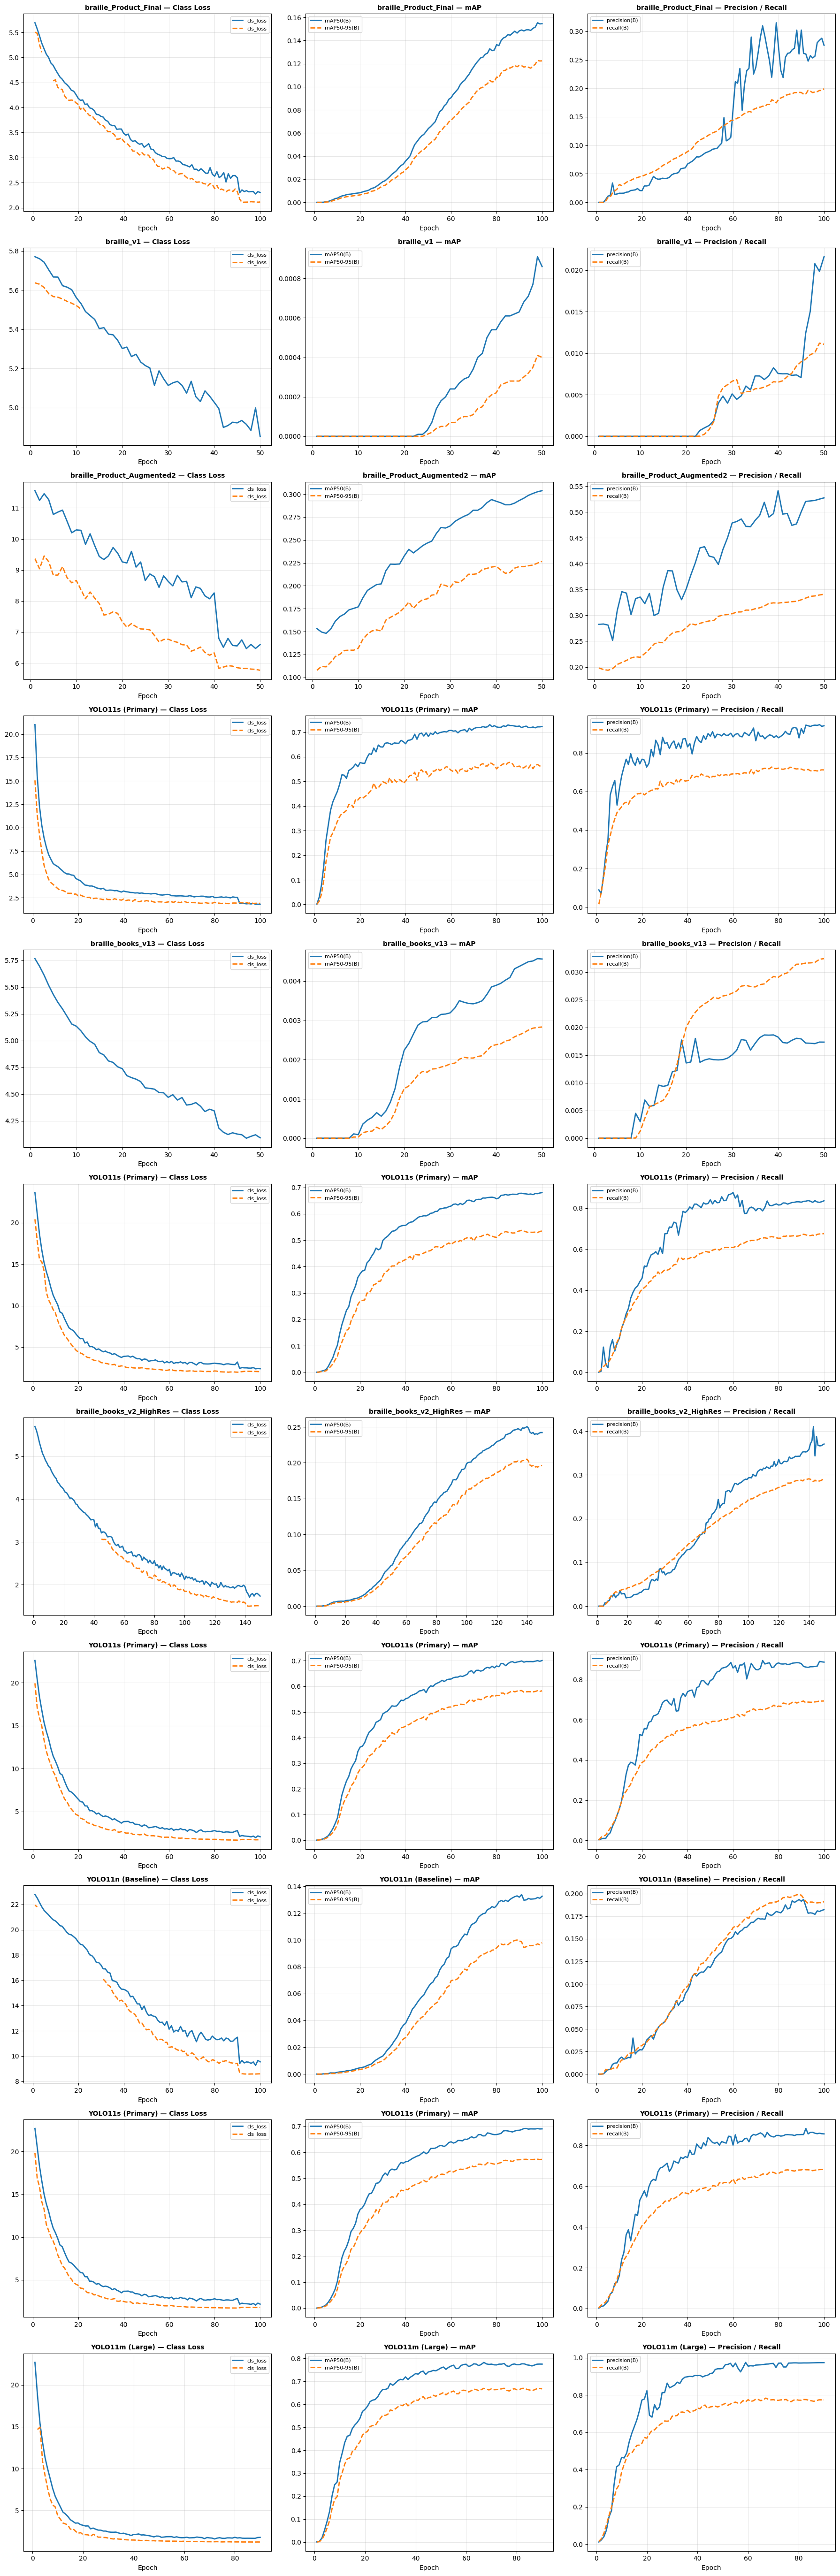

✅ Saved → /content/training_curves_all.png

━━━━  6-B  Running val() on all models  ━━━━
  Evaluating braille_Product_Final ...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,017,933 parameters, 0 gradients, 8.2 GFLOPs
val: Fast image access ✅ (ping: 1.6±0.7 ms, read: 20.3±4.0 MB/s, size: 104.3 KB)
val: Scanning /content/drive/MyDrive/ML Project/AngelinaDataset/books/chudo_derevo_redmi.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.9s/it 5.7s
                   all         32       9139      0.227      0.169      0.134      0.108
Speed: 7.7ms preprocess, 9.5ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/val-6
  Evaluating braille_v1 ...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Mode

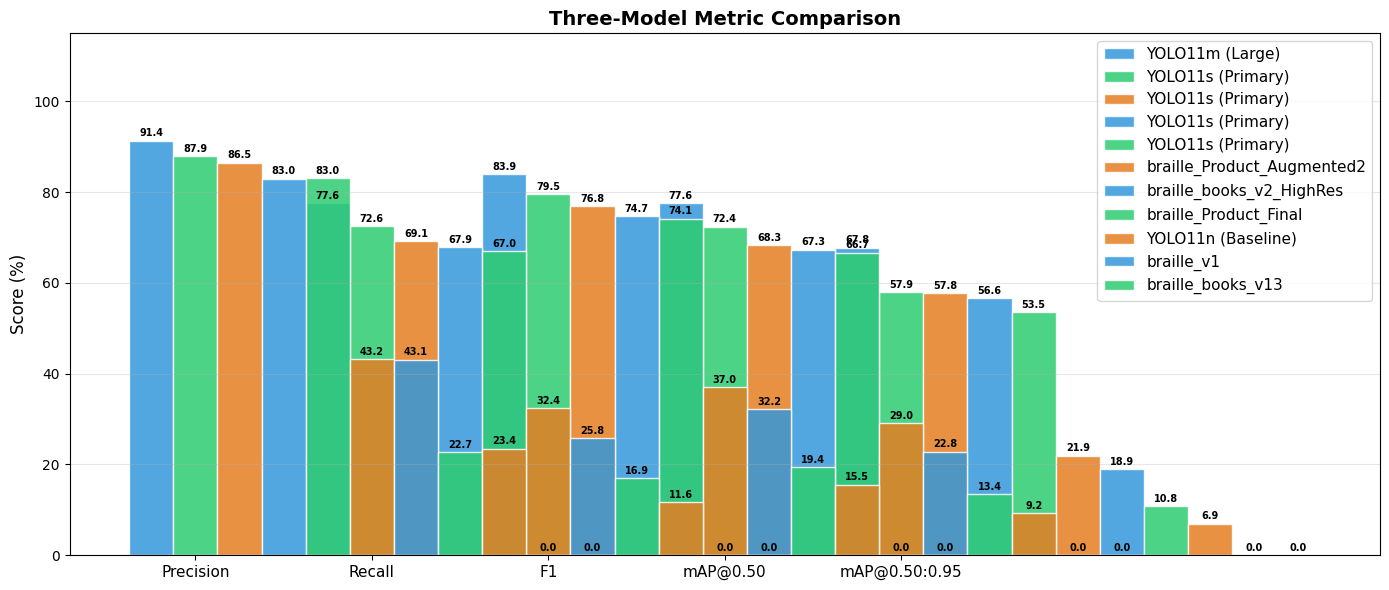

✅ Saved → /content/model_comparison_chart.png

━━━━  6-D  Per-Class AP — YOLO11m (Large)  ━━━━
 Class ID Symbol  Precision  Recall     F1  AP@0.50
       29      t     100.00  100.00 100.00    85.51
       34      <     100.00   95.54  97.72    85.51
       24      d     100.00   95.54  97.72    85.09
       26      g     100.00  100.00 100.00    85.01
       33     er     100.00   92.00  95.83    84.73
       38      v     100.00   93.33  96.55    84.58
       25      j     100.00   94.44  97.14    84.03
       35      -     100.00   93.14  96.45    83.48
        7      #     100.00   97.14  98.55    83.48
       44      #     100.00   91.94  95.80    82.03
       40      x     100.00   91.30  95.45    81.31
       31     ed     100.00   91.67  95.65    80.80
       15      "      99.18   91.67  95.27    80.72
       12      m     100.00   91.06  95.32    80.20
       46      &     100.00   88.24  93.75    80.07
       18      h     100.00   91.48  95.55    80.05
       45    the     

/tmp/ipykernel_58135/880123237.py:207: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58135/880123237.py:207: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58135/880123237.py:207: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58135/880123237.py:208: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/per_class_ap.png',dpi=150,bbox_inches='tight')
/tmp/ipykernel_58135/880123237.py:208: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/per_class_ap.png',dpi=150,bbox_inches='tight')
/tmp/ipykernel_58135/880123237.py:208: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/per_class_ap.png',dpi=150,bbo

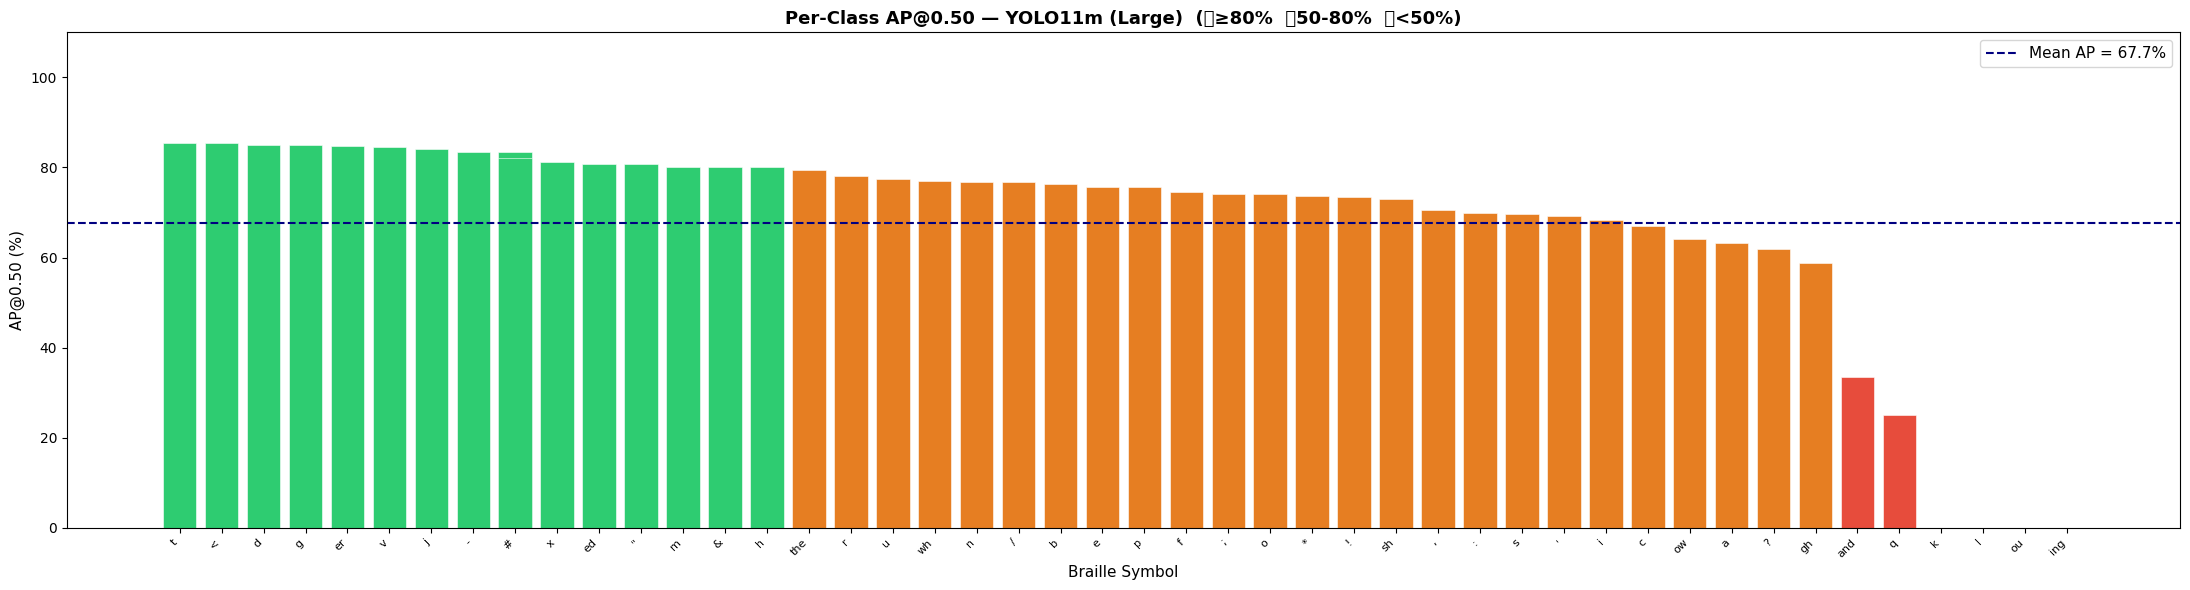

✅ Saved → /content/per_class_ap.png

━━━━  Confusion Matrix (Normalised)  ━━━━


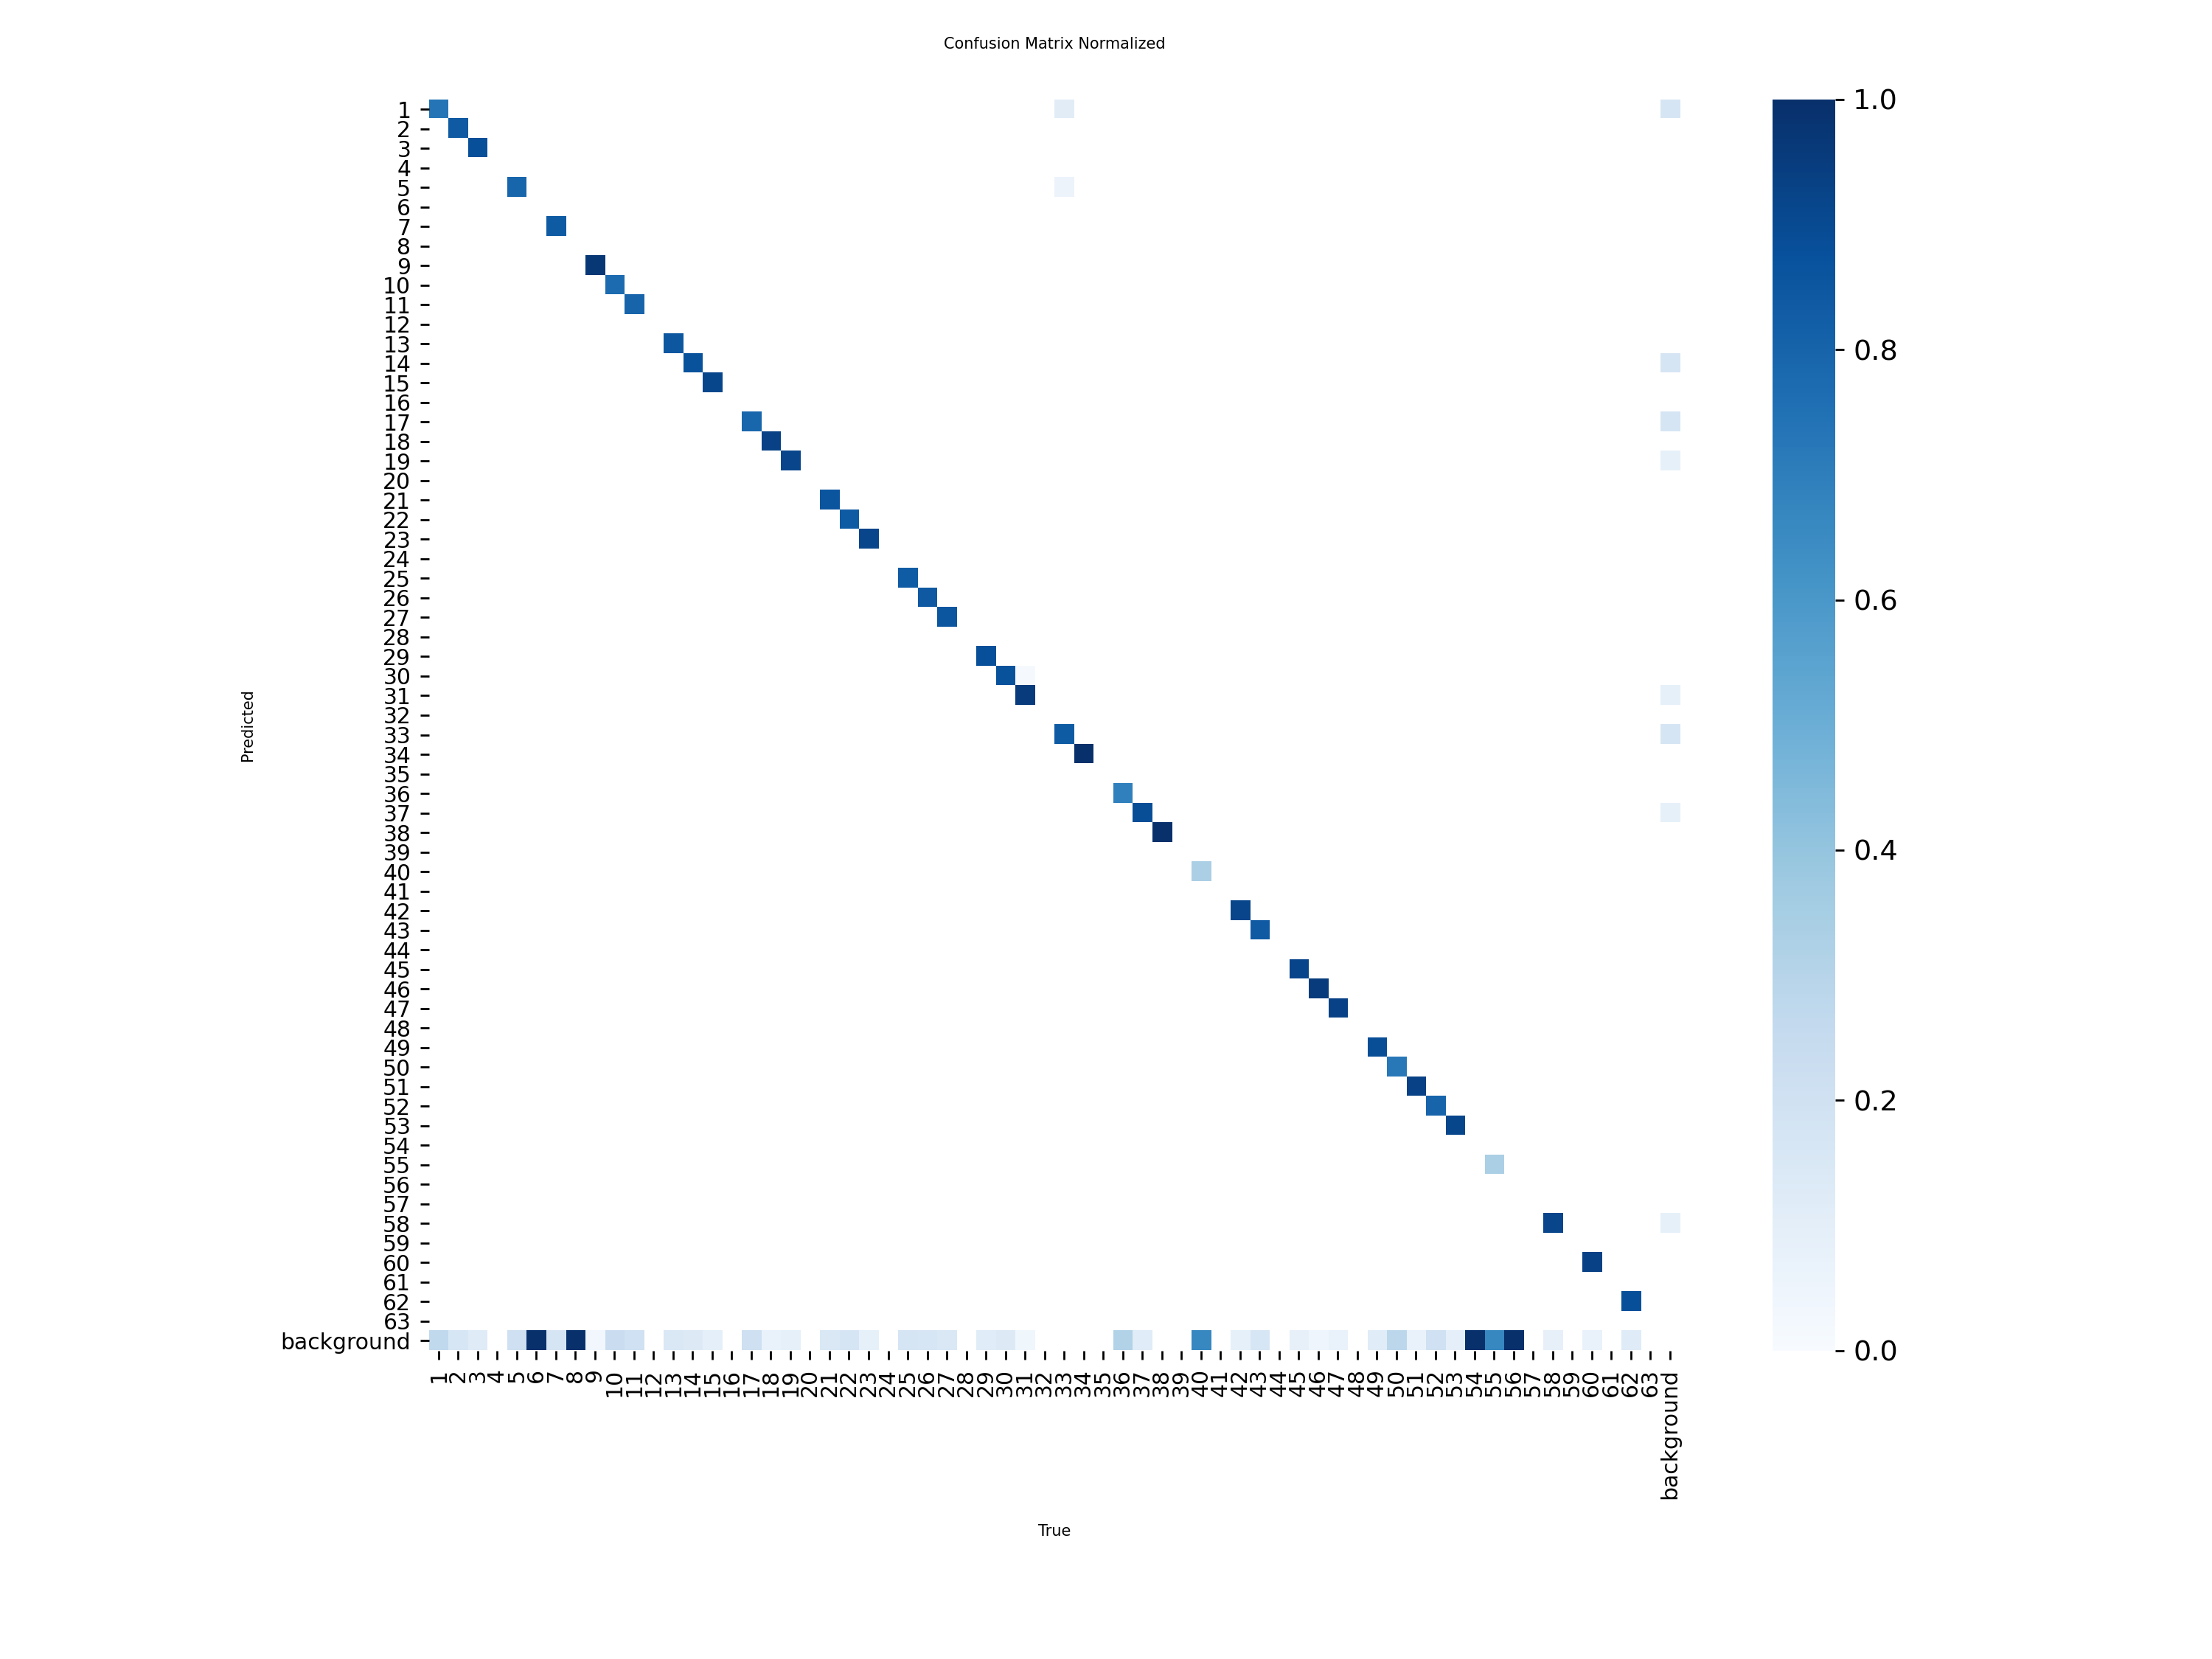


━━━━  6-F  Final Summary Table  ━━━━
         Metric           Value
     Best Model YOLO11m (Large)
      Precision          91.36%
         Recall          77.61%
       F1 Score          83.93%
       F2 Score          80.02%
       mAP@0.50          77.62%
  mAP@0.50:0.95          67.75%
Classes ≥80% AP              16
Classes ≥50% AP              41
Classes <50% AP               6

✅ All outputs saved:
   /content/training_curves_all.png
   /content/model_comparison_chart.png
   /content/model_comparison.csv
   /content/per_class_ap.png
   /content/per_class_metrics.csv
   /content/model_summary.csv



In [1]:
# ══════════════════════════════════════════════════════════════
#  STEP 6 — FULL EVALUATION + 3-MODEL COMPARISON
# ══════════════════════════════════════════════════════════════
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    import subprocess; subprocess.run(['pip','install','ultralytics','-q'], check=True)
    from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────
RUNS_DIR  = '/content/drive/MyDrive/ML Project/YOLO_Runs'
YAML_PATH = '/content/braille_books.yaml'
BASE_PATH = '/content/drive/MyDrive/ML Project/AngelinaDataset/books'

import yaml as _yaml
if not os.path.exists(YAML_PATH):
    with open(YAML_PATH,'w') as _f:
        _yaml.dump({'train':f'{BASE_PATH}/train_all.txt','val':f'{BASE_PATH}/val_all.txt',
                    'nc':63,'names':[str(i+1) for i in range(63)]},_f)
    print('✅ YAML re-created')

# ── Braille label map ─────────────────────────────────────────
braille_labels = {
     0:'a',  1:',',  2:'b',  3:"'", 4:'k',  5:';',  6:'l',  7:'#',
     8:'c',  9:'i', 10:'f', 11:'/',12:'m', 13:'s', 14:'p', 15:'"',
    16:'e', 17:':', 18:'h', 19:'sh',20:'o',21:'!',22:'r',23:'wh',
    24:'d', 25:'j', 26:'g', 27:'gh',28:'n',29:'t',30:'q',31:'ed',
    32:'*', 33:'er',34:'<', 35:'-',36:'u',37:'?',38:'v',39:'ow',
    40:'x', 41:'ou',42:'and',43:'ing',44:'#',45:'the',46:'&',47:'ar',
    48:' ', 49:'.', 50:'[', 51:'en',52:'z',53:'(',54:'with',55:'st',
    56:'of',57:'w', 58:'ch',59:'ble',60:'y',61:')',62:'='
}

# ── Auto-locate all best.pt files ────────────────────────────
all_weights = sorted(
    glob.glob(os.path.join(RUNS_DIR,'**','best.pt'), recursive=True),
    key=os.path.getmtime
)
if not all_weights:
    all_weights = sorted(
        glob.glob('/content/drive/MyDrive/**/best.pt', recursive=True),
        key=os.path.getmtime
    )
if not all_weights:
    raise FileNotFoundError('❌ No best.pt found. Run Step 4 first.')

print(f'🔍 Found {len(all_weights)} model weight(s):')
for w in all_weights: print(f'   {w}')

# ── Name each model from its run folder ───────────────────────
def model_label(path):
    name = os.path.basename(os.path.dirname(os.path.dirname(path)))
    if 'nano' in name.lower() or '11n' in name.lower():  return 'YOLO11n (Baseline)'
    if 'small' in name.lower() or '11s' in name.lower(): return 'YOLO11s (Primary)'
    if 'med' in name.lower()   or '11m' in name.lower(): return 'YOLO11m (Large)'
    return name

# ══════════════════════════════════════════════════════════════
#  6-A  TRAINING CURVES PER MODEL
# ══════════════════════════════════════════════════════════════
print('\n━━━━  6-A  Training Curves  ━━━━')
fig_curves, axes = plt.subplots(len(all_weights), 3, figsize=(18, 5*len(all_weights)))
if len(all_weights) == 1: axes = [axes]

for row, wpath in enumerate(all_weights):
    run_dir = str(Path(wpath).parent.parent)
    csv_path = os.path.join(run_dir,'results.csv')
    label = model_label(wpath)
    if not os.path.exists(csv_path):
        print(f'⚠️  No results.csv for {label}')
        continue
    df = pd.read_csv(csv_path); df.columns = df.columns.str.strip()
    ep = df['epoch'] if 'epoch' in df.columns else range(len(df))
    for col_idx,(tc,vc,title) in enumerate([
        ('train/cls_loss','val/cls_loss','Class Loss'),
        ('metrics/mAP50(B)','metrics/mAP50-95(B)','mAP'),
        ('metrics/precision(B)','metrics/recall(B)','Precision / Recall'),
    ]):
        ax = axes[row][col_idx]
        if tc in df.columns: ax.plot(ep, df[tc], label=tc.split('/')[-1], lw=2)
        if vc in df.columns: ax.plot(ep, df[vc], label=vc.split('/')[-1], lw=2, ls='--')
        ax.set_title(f'{label} — {title}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → /content/training_curves_all.png')

# ══════════════════════════════════════════════════════════════
#  6-B  VALIDATE ALL MODELS — collect scorecard
# ══════════════════════════════════════════════════════════════
print('\n━━━━  6-B  Running val() on all models  ━━━━')
records = []
per_class_results = {}

for wpath in all_weights:
    label = model_label(wpath)
    print(f'  Evaluating {label} ...')
    m = YOLO(wpath)
    met = m.val(data=YAML_PATH, imgsz=1024, conf=0.25, iou=0.5, verbose=False)
    P   = float(met.box.mp)
    R   = float(met.box.mr)
    m50 = float(met.box.map50)
    m95 = float(met.box.map)
    F1  = 2*P*R/(P+R+1e-9)
    F2  = 5*P*R/(4*P+R+1e-9)
    # model size in MB
    size_mb = os.path.getsize(wpath)/1e6
    records.append({
        'Model':label,'Precision':round(P*100,2),'Recall':round(R*100,2),
        'F1':round(F1*100,2),'F2':round(F2*100,2),
        'mAP@0.50':round(m50*100,2),'mAP@0.50:0.95':round(m95*100,2),
        'Size(MB)':round(size_mb,1)
    })
    # store per-class AP for the primary model
    ap = met.box.ap[:,0] if met.box.ap.ndim==2 else met.box.ap
    per_class_results[label] = {
        'ap':ap,'p':met.box.p,'r':met.box.r,'model':m,'metrics':met
    }

compare_df = pd.DataFrame(records)
compare_df = compare_df.sort_values('mAP@0.50', ascending=False).reset_index(drop=True)
print('\n' + '='*70)
print('  📊  MODEL COMPARISON TABLE')
print('='*70)
print(compare_df.to_string(index=False))
compare_df.to_csv('/content/model_comparison.csv', index=False)
print('\n✅ Saved → /content/model_comparison.csv')

# ── Identify best model ───────────────────────────────────────
best_label = compare_df.iloc[0]['Model']
best_map   = compare_df.iloc[0]['mAP@0.50']
print(f'\n🏆 Best model: {best_label}  (mAP@0.50 = {best_map:.2f}%)')
print('   Reasoning: highest mAP@0.50 on held-out validation set with seed=42')

# ══════════════════════════════════════════════════════════════
#  6-C  COMPARISON BAR CHART
# ══════════════════════════════════════════════════════════════
metrics_to_plot = ['Precision','Recall','F1','mAP@0.50','mAP@0.50:0.95']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#3498db','#2ecc71','#e67e22']

fig3, ax3 = plt.subplots(figsize=(14, 6))
for i,(_, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    bars = ax3.bar(x + i*width, vals, width, label=row['Model'],
                   color=colors_bar[i % len(colors_bar)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax3.set_xticks(x + width)
ax3.set_xticklabels(metrics_to_plot, fontsize=11)
ax3.set_ylabel('Score (%)', fontsize=12)
ax3.set_title('Three-Model Metric Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11); ax3.set_ylim(0, 115); ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → /content/model_comparison_chart.png')

# ══════════════════════════════════════════════════════════════
#  6-D  PER-CLASS AP FOR BEST MODEL
# ══════════════════════════════════════════════════════════════
print(f'\n━━━━  6-D  Per-Class AP — {best_label}  ━━━━')
best_data = per_class_results[best_label]
ap  = best_data['ap']
p_c = best_data['p']
r_c = best_data['r']
f1c = 2*p_c*r_c/(p_c+r_c+1e-9)

per_class_df = pd.DataFrame({
    'Class ID': range(len(ap)),
    'Symbol'  : [braille_labels.get(i,str(i)) for i in range(len(ap))],
    'Precision': np.round(p_c*100,2),
    'Recall'  : np.round(r_c*100,2),
    'F1'      : np.round(f1c*100,2),
    'AP@0.50' : np.round(ap*100,2),
}).sort_values('AP@0.50',ascending=False)

print(per_class_df.to_string(index=False))
per_class_df.to_csv('/content/per_class_metrics.csv', index=False)

fig4, ax4 = plt.subplots(figsize=(22,6))
clrs = ['#2ecc71' if v>=80 else '#e67e22' if v>=50 else '#e74c3c'
        for v in per_class_df['AP@0.50']]
ax4.bar(per_class_df['Symbol'], per_class_df['AP@0.50'],
        color=clrs, edgecolor='white', linewidth=0.4)
best_map50 = per_class_df['AP@0.50'].mean()
ax4.axhline(best_map50, color='navy', ls='--', lw=1.5,
            label=f'Mean AP = {best_map50:.1f}%')
ax4.set_xlabel('Braille Symbol',fontsize=11)
ax4.set_ylabel('AP@0.50 (%)',fontsize=11)
ax4.set_title(f'Per-Class AP@0.50 — {best_label}  (🟢≥80%  🟠50-80%  🔴<50%)',
              fontsize=13,fontweight='bold')
ax4.legend(fontsize=11); ax4.set_ylim(0,110)
plt.xticks(rotation=45,ha='right',fontsize=8)
plt.tight_layout()
plt.savefig('/content/per_class_ap.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ Saved → /content/per_class_ap.png')

# ══════════════════════════════════════════════════════════════
#  6-E  CONFUSION MATRIX & BUILT-IN CURVES
# ══════════════════════════════════════════════════════════════
from IPython.display import Image, display
best_run_dir = str(Path(all_weights[
    [model_label(w) for w in all_weights].index(best_label)
]).parent.parent)

for png_name, label in [
    ('confusion_matrix_normalized.png','Confusion Matrix (Normalised)'),
    ('PR_curve.png','Precision–Recall Curve'),
    ('F1_curve.png','F1 Curve'),
    ('P_curve.png','Precision Curve'),
    ('R_curve.png','Recall Curve'),
]:
    src = os.path.join(best_run_dir, png_name)
    if os.path.exists(src):
        print(f'\n━━━━  {label}  ━━━━')
        display(Image(src))

if not glob.glob(os.path.join(best_run_dir,'*.png')):
    print('ℹ️  Regenerating plots via val(plots=True) ...')
    best_data['model'].val(
        data=YAML_PATH, imgsz=1024, conf=0.25, plots=True,
        project=RUNS_DIR, name=os.path.basename(best_run_dir), exist_ok=True
    )

# ══════════════════════════════════════════════════════════════
#  6-F  FINAL SUMMARY
# ══════════════════════════════════════════════════════════════
print('\n━━━━  6-F  Final Summary Table  ━━━━')
best_row = compare_df.iloc[0]
summary_df = pd.DataFrame({
    'Metric':['Best Model','Precision','Recall','F1 Score','F2 Score',
              'mAP@0.50','mAP@0.50:0.95',
              'Classes ≥80% AP','Classes ≥50% AP','Classes <50% AP'],
    'Value':[
        best_label,
        f"{best_row['Precision']:.2f}%", f"{best_row['Recall']:.2f}%",
        f"{best_row['F1']:.2f}%",        f"{best_row['F2']:.2f}%",
        f"{best_row['mAP@0.50']:.2f}%",  f"{best_row['mAP@0.50:0.95']:.2f}%",
        str((per_class_df['AP@0.50']>=80).sum()),
        str((per_class_df['AP@0.50']>=50).sum()),
        str((per_class_df['AP@0.50']< 50).sum()),
    ]
})
print(summary_df.to_string(index=False))
summary_df.to_csv('/content/model_summary.csv', index=False)
print('''
✅ All outputs saved:
   /content/training_curves_all.png
   /content/model_comparison_chart.png
   /content/model_comparison.csv
   /content/per_class_ap.png
   /content/per_class_metrics.csv
   /content/model_summary.csv
''')
